## Hospitality Analysis - Ad-Hoc Analysis

Author - Aditya Dhiman

**Domain:** Hospitality | 
**Tool:** Python (Pandas, Matplotlib, Seaborn)  
**Dataset:** 5 tables - 134K+ bookings across 4 cities, May–Jul 2022  
**Objective:** Perform EDA and Data Visualization to analyse booking patterns and revenue performance | 
**KPIs:** (ADR, RevPAR, Occupancy %, Realization %, Cancellation %) to identify pricing inefficiencies and 
cancellation drivers.

### Dataset Description
| Table | Rows | Description |
|---|---|---|
| fact_bookings | 134,576 | Individual booking transactions |
| fact_aggregated_bookings | ~9,000 | Daily capacity vs successful bookings per property |
| dim_hotels | 25 | Hotel name, city, category (Luxury/Business) |
| dim_rooms | 4 | Room class mapping (RT1–RT4) |
| dim_date | 92 | Date table with week number, day type, month |

In [1]:
# importing the libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

### ==> 1. Data Import and Data Exploration

In [2]:
# Importing data
df_bookings = pd.read_csv("fact_bookings.csv")
df_date = pd.read_csv("dim_date.csv")
df_hotel = pd.read_csv("dim_hotels.csv")
df_room = pd.read_csv("dim_rooms.csv")
df_agg_bookings = pd.read_csv("fact_aggregated_bookings.csv")

In [3]:
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  object 
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  object 
 3   check_in_date      134590 non-null  object 
 4   checkout_date      134590 non-null  object 
 5   no_guests          134587 non-null  float64
 6   room_category      134590 non-null  object 
 7   booking_platform   134590 non-null  object 
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  object 
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(2), int64(3), object(7)
memory usage: 12.3+ MB


In [4]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB


In [5]:
df_agg_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_id          9200 non-null   int64  
 1   check_in_date        9200 non-null   object 
 2   room_category        9200 non-null   object 
 3   successful_bookings  9200 non-null   int64  
 4   capacity             9198 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 359.5+ KB


As we can see that "date" in all three tables is of data type object. We will first change them all to proper date format.

In [6]:
df_date["date"] = pd.to_datetime(df_date["date"], format="mixed", dayfirst=True)
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      92 non-null     datetime64[ns]
 1   mmm yy    92 non-null     object        
 2   week no   92 non-null     object        
 3   day_type  92 non-null     object        
dtypes: datetime64[ns](1), object(3)
memory usage: 3.0+ KB


In [7]:
df_bookings["check_in_date"] = pd.to_datetime(df_bookings["check_in_date"], format="mixed", dayfirst=True)
df_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   booking_id         134590 non-null  object        
 1   property_id        134590 non-null  int64         
 2   booking_date       134590 non-null  object        
 3   check_in_date      134590 non-null  datetime64[ns]
 4   checkout_date      134590 non-null  object        
 5   no_guests          134587 non-null  float64       
 6   room_category      134590 non-null  object        
 7   booking_platform   134590 non-null  object        
 8   ratings_given      56683 non-null   float64       
 9   booking_status     134590 non-null  object        
 10  revenue_generated  134590 non-null  int64         
 11  revenue_realized   134590 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(3), object(6)
memory usage: 12.3+ MB


In [8]:
df_agg_bookings["check_in_date"] = pd.to_datetime(df_agg_bookings["check_in_date"], format="mixed", dayfirst=True)
df_agg_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   property_id          9200 non-null   int64         
 1   check_in_date        9200 non-null   datetime64[ns]
 2   room_category        9200 non-null   object        
 3   successful_bookings  9200 non-null   int64         
 4   capacity             9198 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 359.5+ KB


In [9]:
df_hotel.head(4)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi


In [10]:
df_bookings.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,2022-05-01,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,28-04-22,2022-05-01,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
3,May012216558RT14,16558,28-04-22,2022-05-01,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640


Then, we check how many records the table has using shape() function

In [11]:
df_bookings.shape

(134590, 12)

The fact_bookings_table has 134590 rows and 12 columns

After that, we check basic statistics of numerical data in the table using describe() function

In [12]:
df_bookings.describe()

,property_id,check_in_date,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134590,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2022-06-14 22:52:29.939816960,2.036170,3.619004,1.537805e+04,12696.123256
min,16558.000000,2022-05-01 00:00:00,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,2022-05-23 00:00:00,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2022-06-15 00:00:00,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2022-07-08 00:00:00,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,2022-07-31 00:00:00,6.000000,5.000000,2.856000e+07,45220.000000
std,1093.055847,NaN,1.034885,1.235009,9.303604e+04,6928.108124


As you can see, the revenue_generated is not coming right, we need to use some of the inbuilt functions in pandas for better understanding

In [13]:
df_bookings.revenue_generated.min(), df_bookings.revenue_generated.max(), df_bookings.revenue_generated.std()

(np.int64(6500), np.int64(28560000), np.float64(93036.03867095453))

Now, we do some exploration

In [14]:
# checking unique values in dimension tables
df_bookings.booking_platform.unique()

array(['direct online', 'others', 'logtrip', 'tripster', 'makeyourtrip',
       'journey', 'direct offline'], dtype=object)

In [15]:
# count no of bookings that were done through different platforms
df_bookings.booking_platform.value_counts().sort_values(ascending=False)

booking_platform
others            55066
makeyourtrip      26898
logtrip           14756
direct online     13379
tripster           9630
journey            8106
direct offline     6755
Name: count, dtype: int64

Now, we can go ahead and explore the rest of the tables

In [16]:
df_hotel.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [17]:
df_hotel.shape

(25, 4)

dim_hotels has 25 rows and 4 columns

In [18]:
df_hotel.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

Out of 25, 16 hotels belong to luxury category and 9 belong to business

In [19]:
df_hotel.city.value_counts().sort_values()

city
Delhi        5
Hyderabad    6
Bangalore    6
Mumbai       8
Name: count, dtype: int64

City-wise breakdown of the hotels

In [20]:
df_room

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


In [21]:
df_agg_bookings.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,2022-05-01,RT1,25,30.0
1,19562,2022-05-01,RT1,28,30.0
2,19563,2022-05-01,RT1,23,30.0


In [22]:
df_agg_bookings.shape

(9200, 5)

In [23]:
df_agg_bookings.describe()

,property_id,check_in_date,successful_bookings,capacity
count,9200.000000,9200,9200.000000,9198.000000
mean,18040.640000,2022-06-15 12:00:00,14.655761,25.280496
min,16558.000000,2022-05-01 00:00:00,1.000000,3.000000
25%,17558.000000,2022-05-23 18:00:00,9.000000,18.000000
50%,17564.000000,2022-06-15 12:00:00,14.000000,25.000000
75%,18563.000000,2022-07-08 06:00:00,19.000000,34.000000
max,19563.000000,2022-07-31 00:00:00,123.000000,50.000000
std,1099.818325,NaN,7.736170,11.442080


fact_aggregated_bookings has 9200 rows and 5 columns

In [24]:
# Unique property ids in aggregate bookings dataset
df_agg_bookings.property_id.unique()

array([16559, 19562, 19563, 17558, 16558, 17560, 19558, 19560, 17561,
       16560, 16561, 16562, 16563, 17559, 17562, 17563, 18558, 18559,
       18561, 18562, 18563, 19559, 19561, 17564, 18560])

In [25]:
# Total no of rooms booked per property_id
df_agg_bookings.groupby("property_id")["successful_bookings"].sum()

property_id
16558    3153
16559    7338
16560    4693
16561    4418
16562    4820
16563    7211
17558    5053
17559    6142
17560    6013
17561    5183
17562    3424
17563    6337
17564    3982
18558    4475
18559    5256
18560    6638
18561    6458
18562    7333
18563    4737
19558    4400
19559    4729
19560    6079
19561    5736
19562    5812
19563    5413
Name: successful_bookings, dtype: int64

In [26]:
# Days on which bookings are greater than capacity
df_agg_bookings[df_agg_bookings.successful_bookings>df_agg_bookings.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,2022-05-01,RT1,30,19.0
12,16563,2022-05-01,RT1,100,41.0
4136,19558,2022-06-11,RT2,50,39.0
6209,19560,2022-07-02,RT1,123,26.0
8522,19559,2022-07-25,RT1,35,24.0
9194,18563,2022-07-31,RT4,20,18.0


In [27]:
# Properties that have highest capacity
df_agg_bookings[df_agg_bookings.capacity==df_agg_bookings.capacity.max()]

,property_id,check_in_date,room_category,successful_bookings,capacity
27,17558,2022-05-01,RT2,38,50.0
128,17558,2022-05-02,RT2,27,50.0
229,17558,2022-05-03,RT2,26,50.0
328,17558,2022-05-04,RT2,27,50.0
428,17558,2022-05-05,RT2,29,50.0
...,...,...,...,...,...
8728,17558,2022-07-27,RT2,22,50.0
8828,17558,2022-07-28,RT2,21,50.0
8928,17558,2022-07-29,RT2,23,50.0
9028,17558,2022-07-30,RT2,32,50.0


### ==> 2. Data Cleaning

In [28]:
df_bookings.describe()

,property_id,check_in_date,no_guests,ratings_given,revenue_generated,revenue_realized
count,134590.000000,134590,134587.000000,56683.000000,1.345900e+05,134590.000000
mean,18061.113493,2022-06-14 22:52:29.939816960,2.036170,3.619004,1.537805e+04,12696.123256
min,16558.000000,2022-05-01 00:00:00,-17.000000,1.000000,6.500000e+03,2600.000000
25%,17558.000000,2022-05-23 00:00:00,1.000000,3.000000,9.900000e+03,7600.000000
50%,17564.000000,2022-06-15 00:00:00,2.000000,4.000000,1.350000e+04,11700.000000
75%,18563.000000,2022-07-08 00:00:00,2.000000,5.000000,1.800000e+04,15300.000000
max,19563.000000,2022-07-31 00:00:00,6.000000,5.000000,2.856000e+07,45220.000000
std,1093.055847,NaN,1.034885,1.235009,9.303604e+04,6928.108124


As we can see that the min value of no of guests is -17, we know that atleast 1 guest must stay in the room. This is a data error that we will try to fix

First we check how many records have negative value of guests

In [29]:
df_bookings[df_bookings.no_guests<=0].shape

(9, 12)

Just 9 rows out of 134590 have incorrect data for guests. That is less than 1%, so we can choose to ignore/delete them as it will not skew the data

In [30]:
# revemoving the negative values
df_bookings = df_bookings[df_bookings.no_guests>=0]
df_bookings.shape

(134578, 12)

In [31]:
df_bookings.revenue_generated.max(), df_bookings.revenue_generated.min()

(np.int64(28560000), np.int64(6500))

We can see that maximum rent for one night is in millions. It maybe an outlier, We will prove and check how many outliers are there using the 3 standard deviation rule

In [32]:
avg, std = df_bookings.revenue_generated.mean(), df_bookings.revenue_generated.std()
avg, std

(np.float64(15378.036937686695), np.float64(93040.1549314641))

In [33]:
# higher limit - values on the higher side must be below 3 std devs away from mean
higher_limit = avg + 3*std
higher_limit

np.float64(294498.50173207896)

The maximum rent that a room should be 294498, but the maximum value was much larger. It is an outlier

In [34]:
# bookings where revenue generated is an outlier
df_bookings[df_bookings.revenue_generated>higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
2,May012216558RT13,16558,28-04-22,2022-05-01,4/5/2022,2.0,RT1,logtrip,5.0,Checked Out,9100000,9100
111,May012216559RT32,16559,29-04-22,2022-05-01,2/5/2022,6.0,RT3,direct online,NaN,Checked Out,28560000,28560
315,May012216562RT22,16562,28-04-22,2022-05-01,4/5/2022,2.0,RT2,direct offline,3.0,Checked Out,12600000,12600
562,May012217559RT118,17559,26-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,2000000,4420
129176,Jul282216562RT26,16562,21-07-22,2022-07-28,29-07-22,2.0,RT2,direct online,3.0,Checked Out,10000000,12600


There are 5 rows where the rent was above the higher_limit. So we can deal with them by choosing to ignore them.

In [35]:
# cleaning the outliers (removing them)
df_bookings = df_bookings[df_bookings.revenue_generated<higher_limit]
df_bookings.shape

(134573, 12)

In [36]:
df_bookings.revenue_realized.describe()

count    134573.000000
mean      12695.983585
std        6927.791692
min        2600.000000
25%        7600.000000
50%       11700.000000
75%       15300.000000
max       45220.000000
Name: revenue_realized, dtype: float64

In [37]:
# we check if the max revenue realized is valid or an outlier
higher_limit = df_bookings.revenue_realized.mean() + 3*df_bookings.revenue_realized.std()
higher_limit

np.float64(33479.358661845814)

In [38]:
df_bookings[df_bookings.revenue_realized>higher_limit]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
137,May012216559RT41,16559,27-04-22,2022-05-01,7/5/2022,4.0,RT4,others,NaN,Checked Out,38760,38760
139,May012216559RT43,16559,1/5/2022,2022-05-01,2/5/2022,6.0,RT4,tripster,3.0,Checked Out,45220,45220
143,May012216559RT47,16559,28-04-22,2022-05-01,3/5/2022,3.0,RT4,others,5.0,Checked Out,35530,35530
149,May012216559RT413,16559,24-04-22,2022-05-01,7/5/2022,5.0,RT4,logtrip,NaN,Checked Out,41990,41990
222,May012216560RT45,16560,30-04-22,2022-05-01,3/5/2022,5.0,RT4,others,3.0,Checked Out,34580,34580
...,...,...,...,...,...,...,...,...,...,...,...,...
134328,Jul312219560RT49,19560,31-07-22,2022-07-31,2/8/2022,6.0,RT4,direct online,5.0,Checked Out,39900,39900
134331,Jul312219560RT412,19560,31-07-22,2022-07-31,1/8/2022,6.0,RT4,others,2.0,Checked Out,39900,39900
134467,Jul312219562RT45,19562,28-07-22,2022-07-31,1/8/2022,6.0,RT4,makeyourtrip,4.0,Checked Out,39900,39900
134474,Jul312219562RT412,19562,25-07-22,2022-07-31,6/8/2022,5.0,RT4,direct offline,5.0,Checked Out,37050,37050


We can see that the table has 1300 rows where revenue_realized was higher than the higher_limit and all of them belong to RT4 room category, We need to conduct further analysis.

In [39]:
df_room

,room_id,room_class
0,RT1,Standard
1,RT2,Elite
2,RT3,Premium
3,RT4,Presidential


One observation we can have in above dataframe is that all rooms are RT4 which means presidential suit. Now since RT4 is a luxurious room it is likely their rent will be higher. To make a fair analysis, we need to do data analysis only on RT4 room types

In [40]:
# Revenue analysis of RT4 rooms
df_bookings[df_bookings.room_category=="RT4"].revenue_realized.describe()

count    16071.000000
mean     23439.308444
std       9048.599076
min       7600.000000
25%      19000.000000
50%      26600.000000
75%      32300.000000
max      45220.000000
Name: revenue_realized, dtype: float64

In [41]:
# revenue realized higher limit
23439 + 3*9048

50583

Here higher limit comes to be 50583 and in our dataframe above we can see that max value for revenue realized is 45220. Hence we can conclude that there is no outlier and we don't need to do any data cleaning on this particular column

Now we check for null values

In [42]:
df_bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

Only ratings column as NA values of approx 80K, if we try to change them with statistical methods, It will skew the data. Therefore, we are keeping them, we can argue that not all customers rate their stay.

In [43]:
df_bookings.describe()

,property_id,check_in_date,no_guests,ratings_given,revenue_generated,revenue_realized
count,134573.000000,134573,134573.000000,56676.000000,134573.000000,134573.000000
mean,18061.191658,2022-06-14 22:57:01.649216512,2.036716,3.619045,14915.959776,12695.983585
min,16558.000000,2022-05-01 00:00:00,1.000000,1.000000,6500.000000,2600.000000
25%,17558.000000,2022-05-23 00:00:00,1.000000,3.000000,9900.000000,7600.000000
50%,17564.000000,2022-06-15 00:00:00,2.000000,4.000000,13500.000000,11700.000000
75%,18563.000000,2022-07-08 00:00:00,2.000000,5.000000,18000.000000,15300.000000
max,19563.000000,2022-07-31 00:00:00,6.000000,5.000000,45220.000000,45220.000000
std,1093.042273,NaN,1.031673,1.234983,6452.676164,6927.791692


fact_bookings has been cleaned

In [44]:
# Now, we move to second fact table
df_agg_bookings.describe()

,property_id,check_in_date,successful_bookings,capacity
count,9200.000000,9200,9200.000000,9198.000000
mean,18040.640000,2022-06-15 12:00:00,14.655761,25.280496
min,16558.000000,2022-05-01 00:00:00,1.000000,3.000000
25%,17558.000000,2022-05-23 18:00:00,9.000000,18.000000
50%,17564.000000,2022-06-15 12:00:00,14.000000,25.000000
75%,18563.000000,2022-07-08 06:00:00,19.000000,34.000000
max,19563.000000,2022-07-31 00:00:00,123.000000,50.000000
std,1099.818325,NaN,7.736170,11.442080


In [45]:
#checking for null values
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               2
dtype: int64

In [46]:
df_agg_bookings[df_agg_bookings.capacity.isnull()]

,property_id,check_in_date,room_category,successful_bookings,capacity
8,17561,2022-05-01,RT1,22,NaN
14,17562,2022-05-01,RT1,12,NaN


There are 2 NaN values in capacity column of the dataset. Now we will fill it using basic statistics, choosing median in this case

In [47]:
df_agg_bookings.capacity = df_agg_bookings.capacity.fillna(df_agg_bookings.capacity.median())

In [48]:
df_agg_bookings.isnull().sum()

property_id            0
check_in_date          0
room_category          0
successful_bookings    0
capacity               0
dtype: int64

We have successfully handeled the missing values. Now we move on to checking for errors in the data

In [49]:
df_agg_bookings[df_agg_bookings.successful_bookings>df_agg_bookings.capacity]

,property_id,check_in_date,room_category,successful_bookings,capacity
3,17558,2022-05-01,RT1,30,19.0
12,16563,2022-05-01,RT1,100,41.0
4136,19558,2022-06-11,RT2,50,39.0
6209,19560,2022-07-02,RT1,123,26.0
8522,19559,2022-07-25,RT1,35,24.0
9194,18563,2022-07-31,RT4,20,18.0


We can see that in some records, successful_bookings are greater than capacity, which is logically incorrect. So, we will need to handle these values. Since, these are just 8 records, and total records in fact_agg_bookings is 9200. We can delete these records for better analysis.

In [50]:
df_agg_bookings = df_agg_bookings[df_agg_bookings.successful_bookings<=df_agg_bookings.capacity]
df_agg_bookings.shape

(9194, 5)

### ==> 3. Insights Generation - Ad-Hoc Analysis

**1. What is an average occupancy rate in each of the room categories?**

In [51]:
# calculating out occupancy % per property = successfull_bookings / capacity
df_agg_bookings["occ_pct"]=df_agg_bookings["successful_bookings"]/df_agg_bookings["capacity"]*100
df_agg_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,2022-05-01,RT1,25,30.0,83.333333
1,19562,2022-05-01,RT1,28,30.0,93.333333
2,19563,2022-05-01,RT1,23,30.0,76.666667
4,16558,2022-05-01,RT1,18,19.0,94.736842
5,17560,2022-05-01,RT1,28,40.0,70.000000


In [52]:
# We need to merge df_agg_bookings with df_room to get room categories using merge() function of pandas
df_agg_bookings_rc = pd.merge(df_agg_bookings, df_room, left_on="room_category", right_on="room_id")
df_agg_bookings_rc.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_id,room_class
0,16559,2022-05-01,RT1,25,30.0,83.333333,RT1,Standard
1,19562,2022-05-01,RT1,28,30.0,93.333333,RT1,Standard
2,19563,2022-05-01,RT1,23,30.0,76.666667,RT1,Standard
3,16558,2022-05-01,RT1,18,19.0,94.736842,RT1,Standard
4,17560,2022-05-01,RT1,28,40.0,70.000000,RT1,Standard


In [53]:
df_agg_bookings_rc.groupby("room_class")["occ_pct"].mean().round(2).sort_values(ascending=False)

room_class
Presidential    59.28
Premium         58.03
Elite           58.01
Standard        57.89
Name: occ_pct, dtype: float64

We can see that Presidential suites has the highest occupancy rate in all of the room categories, while standard is the lowest in occupany rate

In [54]:
# We can now drop the extra column in df_agg_bookings_city
df_agg_bookings_rc.drop("room_id", axis=1, inplace=True)
df_agg_bookings_rc.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class
0,16559,2022-05-01,RT1,25,30.0,83.333333,Standard
1,19562,2022-05-01,RT1,28,30.0,93.333333,Standard
2,19563,2022-05-01,RT1,23,30.0,76.666667,Standard
3,16558,2022-05-01,RT1,18,19.0,94.736842,Standard
4,17560,2022-05-01,RT1,28,40.0,70.000000,Standard


**2. Print average occupancy rate per city**

In [55]:
df_hotel.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


As city information is given in df_hotel, We will now merge it with df_agg_bookings_rc using property_id column

In [56]:
df_agg_bookings_city = pd.merge(df_agg_bookings_rc, df_hotel, on = "property_id")
df_agg_bookings_city.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city
0,16559,2022-05-01,RT1,25,30.0,83.333333,Standard,Atliq Exotica,Luxury,Mumbai
1,19562,2022-05-01,RT1,28,30.0,93.333333,Standard,Atliq Bay,Luxury,Bangalore
2,19563,2022-05-01,RT1,23,30.0,76.666667,Standard,Atliq Palace,Business,Bangalore
3,16558,2022-05-01,RT1,18,19.0,94.736842,Standard,Atliq Grands,Luxury,Delhi
4,17560,2022-05-01,RT1,28,40.0,70.000000,Standard,Atliq City,Business,Mumbai


In [57]:
df_agg_bookings_city.groupby("city")["occ_pct"].mean().round(2).sort_values(ascending=False)

city
Delhi        61.51
Hyderabad    58.12
Mumbai       57.91
Bangalore    56.33
Name: occ_pct, dtype: float64

Delhi has the highest occupancy percentage out of all the cities, while banglore has the lowest.

**3. When was the occupancy better? Weekday or Weekend?**

In [58]:
df_date.head()

,date,mmm yy,week no,day_type
0,2022-05-01,May 22,W 19,weekend
1,2022-05-02,May 22,W 19,weekeday
2,2022-05-03,May 22,W 19,weekeday
3,2022-05-04,May 22,W 19,weekeday
4,2022-05-05,May 22,W 19,weekeday


As the day_type is present in the date table, we will have to merge it with df_agg_bookings_city for answering the question.

In [59]:
df_agg_bookings_all = pd.merge(df_agg_bookings_city, df_date, left_on = "check_in_date", right_on = "date")
df_agg_bookings_all.head(3)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,16559,2022-05-01,RT1,25,30.0,83.333333,Standard,Atliq Exotica,Luxury,Mumbai,2022-05-01,May 22,W 19,weekend
1,19562,2022-05-01,RT1,28,30.0,93.333333,Standard,Atliq Bay,Luxury,Bangalore,2022-05-01,May 22,W 19,weekend
2,19563,2022-05-01,RT1,23,30.0,76.666667,Standard,Atliq Palace,Business,Bangalore,2022-05-01,May 22,W 19,weekend


In [60]:
df_agg_bookings_all.groupby("day_type")["occ_pct"].mean().round(2)

day_type
weekeday    51.81
weekend     73.96
Name: occ_pct, dtype: float64

We can clearly see that weekend sees more occupancy rate than weekdays.

**4: In the month of June, what is the occupancy for different cities**

First, we need to filer the data for just June month

In [61]:
df_jun_22_occ = df_agg_bookings_all[df_agg_bookings_all["mmm yy"]=="Jun 22"]
df_jun_22_occ.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,room_class,property_name,category,city,date,mmm yy,week no,day_type
3098,16559,2022-06-01,RT1,14,30.0,46.666667,Standard,Atliq Exotica,Luxury,Mumbai,2022-06-01,Jun 22,W 23,weekeday
3099,18560,2022-06-01,RT1,18,30.0,60.000000,Standard,Atliq City,Business,Hyderabad,2022-06-01,Jun 22,W 23,weekeday
3100,19562,2022-06-01,RT1,18,30.0,60.000000,Standard,Atliq Bay,Luxury,Bangalore,2022-06-01,Jun 22,W 23,weekeday
3101,19563,2022-06-01,RT1,14,30.0,46.666667,Standard,Atliq Palace,Business,Bangalore,2022-06-01,Jun 22,W 23,weekeday
3102,17558,2022-06-01,RT1,8,19.0,42.105263,Standard,Atliq Grands,Luxury,Mumbai,2022-06-01,Jun 22,W 23,weekeday


In [62]:
df_jun_22_occ.groupby("city")["occ_pct"].mean().round(2).sort_values(ascending=False)

city
Delhi        61.46
Mumbai       57.79
Hyderabad    57.69
Bangalore    55.85
Name: occ_pct, dtype: float64

In the month of June, we can see that Delhi has the highest occ_pct and banglore is at the lowest

**5. Print revenue realized per city**

As df_bookings does not contain city information, we need to merge it with df_hotel using  merge() function

In [63]:
df_bookings_city = pd.merge(df_bookings, df_hotel, on = "property_id")
df_bookings_city.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi


In [64]:
df_bookings_city.groupby("city")["revenue_realized"].sum().sort_values(ascending=False)

city
Mumbai       668569251
Bangalore    420383550
Hyderabad    325179310
Delhi        294404488
Name: revenue_realized, dtype: int64

We can see that Mumbai records the highest revenue_realized, while Delhi has the lowest total revenue_realized.

**6. Month on Month revenue realized**

In [65]:
df_bookings_city.head(4)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi


We need to get month columns from the df_date to df_bookings_city.

In [66]:
df_bookings_all = pd.merge(df_bookings_city, df_date, left_on="check_in_date", right_on="date")
df_bookings_all.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,property_name,category,city,date,mmm yy,week no,day_type
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend


In [67]:
df_bookings_all.groupby("mmm yy")["revenue_realized"].sum().sort_values(ascending=False)

mmm yy
May 22    581767396
Jul 22    572843348
Jun 22    553925855
Name: revenue_realized, dtype: int64

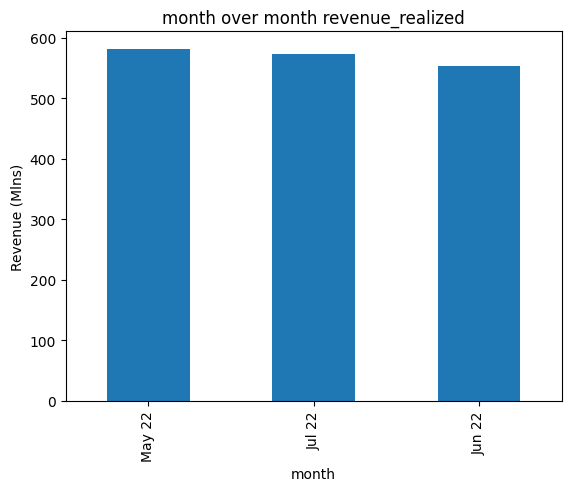

In [68]:
df_bookings_all.groupby("mmm yy")["revenue_realized"].sum().div(1e6).sort_values(ascending=False).plot(
    kind = "bar", title="month over month revenue_realized")
plt.ylabel("Revenue (Mlns)")
plt.xlabel("month")
plt.show()

Altough the difference is not much, we can see that revenue_realized is the lowest in month of June 22. 

**7. Average rating per city**

In [69]:
df_bookings_all.groupby("city")["ratings_given"].mean().round(2).sort_values(ascending=False)

city
Delhi        3.78
Hyderabad    3.66
Mumbai       3.65
Bangalore    3.41
Name: ratings_given, dtype: float64

No significant difference in ratings of the hotels across the 4 cities

**8. A pie chart of revenue realized per booking platform**

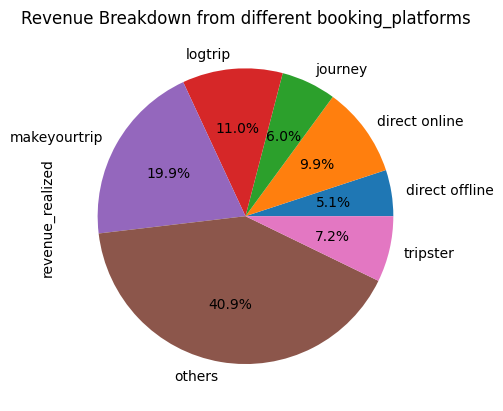

In [70]:
df_bookings_all.groupby("booking_platform")["revenue_realized"].sum().plot(kind = "pie", autopct = "%1.1f%%")
plt.title("Revenue Breakdown from different booking_platforms")
plt.show()

**9. Build monthly aggregations for Occupancy Percentage and ADR and plot them**

In [71]:
# To calculate monthly ADR, we need to get total revenue and count of bookings for each month.
adr_monthly = df_bookings_all.groupby("mmm yy").agg(
    revenue=("revenue_realized", "sum"),
    bookings=("booking_id", "count")
).reset_index()

print(adr_monthly)

   mmm yy    revenue  bookings
0  Jul 22  572843348     45022
1  Jun 22  553925855     43682
2  May 22  581767396     45869


In [72]:
# ADR (Average Daily Rate) = Total Revenue/ Count of Bookings
adr_monthly["ADR"] = (adr_monthly["revenue"] / adr_monthly["bookings"]).round(2)
adr_monthly

,mmm yy,revenue,bookings,ADR
0,Jul 22,572843348,45022,12723.63
1,Jun 22,553925855,43682,12680.87
2,May 22,581767396,45869,12683.24


We got the monthy ADR, now we will calculate monthly occupancy % using same approach

In [73]:
# To calculate monthly Occupancy %, we need to get total successful bookings and total capacity for each month.
occ_monthly = df_agg_bookings_all.groupby("mmm yy").agg(
    successful=("successful_bookings", "sum"),
    capacity=("capacity","sum")
).reset_index()
# Occupancy % = total_successfull_bookings / total_capacity
occ_monthly["occ_pct"]= (occ_monthly.successful/occ_monthly.capacity*100).round(2)

occ_monthly

,mmm yy,successful,capacity,occ_pct
0,Jul 22,44980,78300.0,57.45
1,Jun 22,43662,75801.0,57.60
2,May 22,45833,78312.0,58.53


We got the monthy ADR, now we will join the two tables using month column

In [74]:
monthly_trends = pd.merge(adr_monthly, occ_monthly, on="mmm yy")
monthly_trends

,mmm yy,revenue,bookings,ADR,successful,capacity,occ_pct
0,Jul 22,572843348,45022,12723.63,44980,78300.0,57.45
1,Jun 22,553925855,43682,12680.87,43662,75801.0,57.60
2,May 22,581767396,45869,12683.24,45833,78312.0,58.53


Now, we will plot a line graph for showing the monthly trend of Occupancy % and ADR

In [75]:
# sorting monyhly_trends using categorical() function in pandas
month_order = ["May 22", "Jun 22", "Jul 22"]
monthly_trends["mmm yy"] = pd.Categorical( 
    monthly_trends["mmm yy"],
    categories=month_order,
    ordered=True )
monthly_trends = monthly_trends.sort_values("mmm yy")

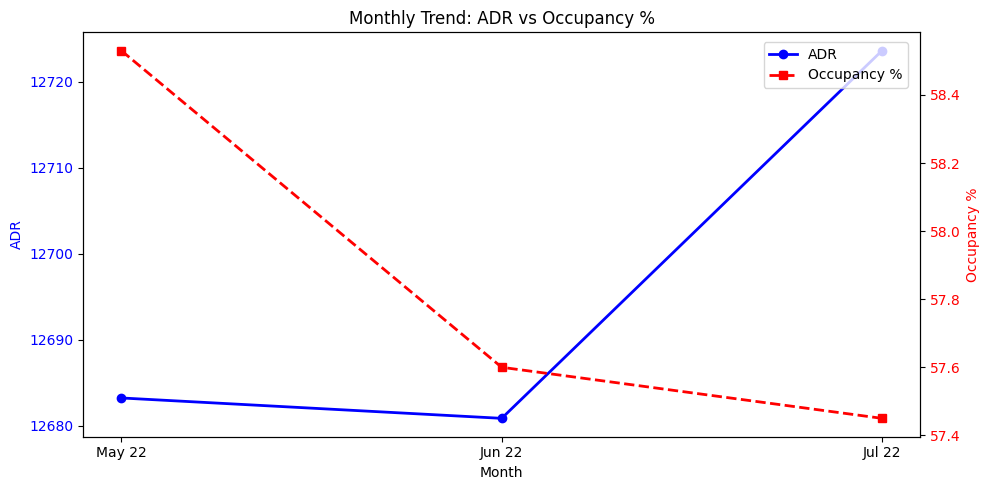

In [76]:
# Plotting the line graph with dual axis
fig, ax1 = plt.subplots(figsize=(10, 5))

# ADR on primary axis
ax1.set_xlabel("Month")
ax1.set_ylabel("ADR", color="blue")
ax1.plot(monthly_trends["mmm yy"], monthly_trends["ADR"], 
         color="blue", marker="o", linewidth=2, label="ADR")
ax1.tick_params(axis="y", labelcolor="blue")

# Occupancy % on secondary axis
ax2 = ax1.twinx()
ax2.set_ylabel("Occupancy %", color="red")
ax2.plot(monthly_trends["mmm yy"], monthly_trends["occ_pct"], 
         color="red", marker="s", linewidth=2, 
         linestyle="--", label="Occupancy %")
ax2.tick_params(axis="y", labelcolor="red")

# Title and legend
plt.title("Monthly Trend: ADR vs Occupancy %")
fig.legend(loc="upper right", bbox_to_anchor=(0.92, 0.92))
plt.tight_layout()
plt.show()

An inverse relationship exists between ADR and Occupancy % across May–Jul 2022. This confirms a pricing inefficiency: the business is not optimising both metrics simultaneously. A dynamic pricing strategy (higher ADR during high-demand periods without sacrificing occupancy) could significantly improve RevPAR.

**10. Find out revenue per booking platform and plot it**

In [77]:
#Calculating revenue per booking from different booking platforms
platform_rev = df_bookings_all.groupby("booking_platform").agg(
    revenue=("revenue_realized","sum"),
    bookings=("booking_id", "count")
).reset_index()
platform_rev["revenue_per_booking"] = (platform_rev["revenue"]/platform_rev["bookings"]).round(2)

platform_rev

,booking_platform,revenue,bookings,revenue_per_booking
0,direct offline,86374933,6753,12790.60
1,direct online,168948637,13374,12632.62
2,journey,102531334,8106,12648.82
3,logtrip,187494028,14753,12708.87
4,makeyourtrip,340814104,26896,12671.55
5,others,699306762,55061,12700.58
6,tripster,123066801,9630,12779.52


<Axes: title={'center': 'Revenue per Booking by Platform'}, ylabel='booking_platform'>

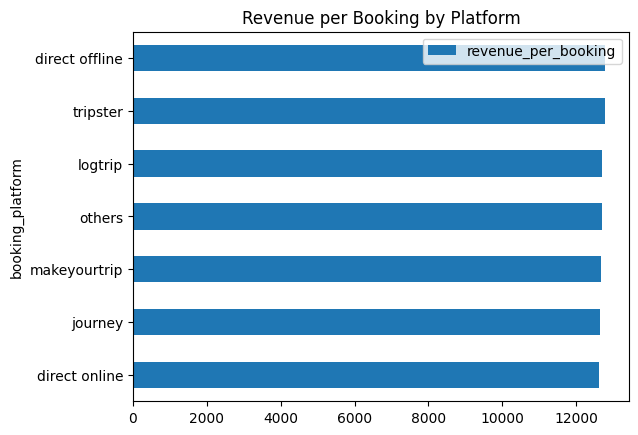

In [78]:
# Plotting the graph
platform_rev.sort_values("revenue_per_booking").plot(
    x="booking_platform", y="revenue_per_booking",
    kind="barh", title="Revenue per Booking by Platform")

The gap between the highest and lowest revenue-per-booking platforms is surprisingly narrow, This suggests platform choice has minimal impact on per-booking revenue. However, Direct Offline bookings likely involve higher-value customers (corporate, luxury) who prefer personal interaction

**11. Find out Cancellation rate per city**

In [79]:
cancellation_city = df_bookings_all.groupby("city").agg(
    total_bookings =("booking_id", "count"),
    cancelled =("booking_status", lambda x : (x=="Cancelled").sum())
).reset_index()
cancellation_city["rate"]=(cancellation_city["cancelled"]/cancellation_city["total_bookings"]*100).round(2)
cancellation_city

,city,total_bookings,cancelled,rate
0,Bangalore,32015,8002,24.99
1,Delhi,24223,6071,25.06
2,Hyderabad,34883,8590,24.63
3,Mumbai,43452,10753,24.75


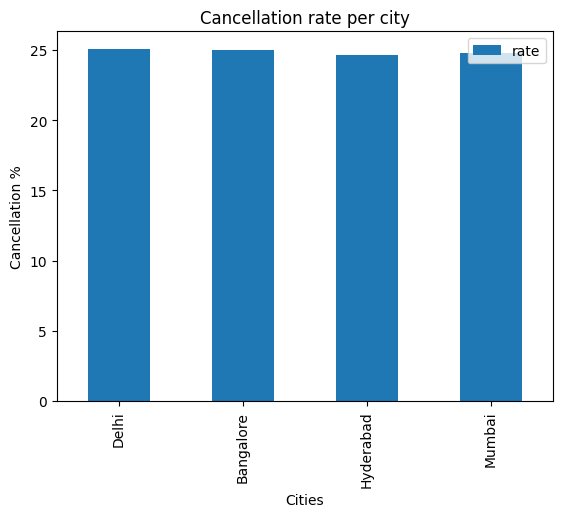

In [80]:
# Plotting a graph
cancellation_city.sort_values("cancelled").plot(x="city", y="rate",
                      kind="bar", title = "Cancellation rate per city"
)
plt.xlabel("Cities")
plt.ylabel("Cancellation %")
plt.show()

As we can see that cancellations are a systemic issue across all markets, not isolated to one city. No city is significantly outperforming others, suggesting the root cause lies in booking policies, prepayment structure, or platform behaviour rather than city-specific demand patterns.

 **12. Find out the Correlation between room class and ratings**

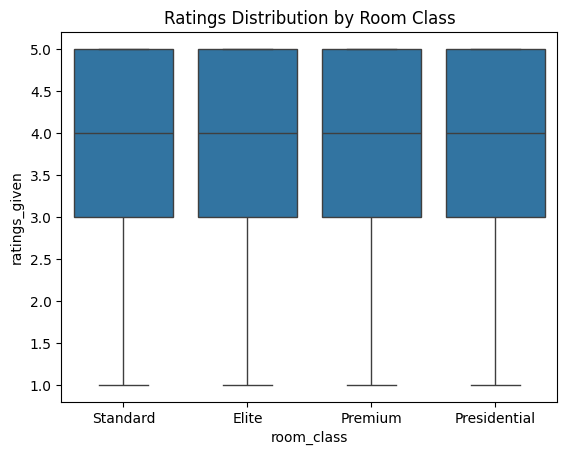

In [81]:
import seaborn as sns
df_rated = pd.merge(df_bookings_all, df_room, left_on="room_category", right_on="room_id")
sns.boxplot(
    data=df_rated,
    x="room_class",
    y="ratings_given"
)

plt.title("Ratings Distribution by Room Class")
plt.show()

Ratings are consistent across all room classes, guests rate their overall hotel experience rather than the room tier specifically. Improving service quality across all tiers is more impactful than focusing on premium room upgrades alone.